### 과제 3

In [1]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 ---
# VENDOR_ANALYSIS_PATH와 GICS_PATH가 올바른지 확인해주세요.
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

GICS_LEVELS = ['sector', 'industry_group', 'industry', 'sub_industry']

# --- 1. 데이터 로드 및 시그널 필터링 ---
print("-> 1. 데이터 로드 및 시그널 필터링 시작...")

try:
    df_analysis = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'surprise_z', 'return_post_1d', 'return_post_2d'],
        dtype={'surprise_z': np.float32, 'return_post_1d': np.float32, 'return_post_2d': np.float32}
    ).dropna(subset=['surprise_z', 'return_post_1d'])

    MEAN_Z_SCORE = df_analysis['surprise_z'].mean() 
    STD_Z_SCORE = df_analysis['surprise_z'].std() 
    
    # Positive Signal인 행만 필터링 (Z > +2σ)
    is_positive_signal = df_analysis['surprise_z'] > MEAN_Z_SCORE + 2 * STD_Z_SCORE
    df_positive_reaction = df_analysis[is_positive_signal].copy()
    
    if df_positive_reaction.empty:
        print("분석: Positive Signal 데이터가 없어 산업별 민감도 분석을 건너뜁니다.")
        exit()

    df_gics = pd.read_csv(GICS_PATH, dtype={c: np.float16 for c in GICS_LEVELS})
    
    # GICS와 Positive Signal 데이터 병합
    df_merged = pd.merge(df_positive_reaction, df_gics, on='symbol', how='left')
    df_merged = df_merged.dropna(subset=['sector', 'return_post_1d'])
    
    print(f"✅ 데이터 통합 및 필터링 완료. 분석 대상 데이터 수: {len(df_merged)}개")

except FileNotFoundError as e:
    print(f"❌ 오류: 필요한 파일을 찾을 수 없습니다. 경로를 확인하세요: {e}")
    exit()
except Exception as e:
    print(f"❌ 오류: 데이터 처리 중 예상치 못한 오류 발생: {e}")
    exit()


# --- 2. 산업별 민감도 분석 (그룹핑 및 출력) ---

print(f"➡️ GICS '{GICS_LEVELS[0]}' 레벨별 민감도 분석 시작...")

# 그룹핑 및 평균 수익률 계산
df_gics_sensitivity = df_merged.groupby(GICS_LEVELS[0])[['return_post_1d', 'return_post_2d']].mean()
df_gics_sensitivity = df_gics_sensitivity.mul(100).round(3) 
df_gics_sensitivity = df_gics_sensitivity.rename(columns={'return_post_1d': 'Avg_Return_Post_1D (%)', 'return_post_2d': 'Avg_Return_Post_2D (%)'})


# --- 3. 최종 결과 출력 및 저장 ---
OUT_ANALYSIS_FILE = os.path.join(OUT_DIR, "problem3_gics_sensitivity.csv")
df_gics_sensitivity.to_csv(OUT_ANALYSIS_FILE)

print(f"\n[OK] 산업별 민감도 분석 결과 저장 완료: {OUT_ANALYSIS_FILE}")

print("\n" + "="*70)
print(f"과제 3: Positive Signal (Long)에 대한 GICS '{GICS_LEVELS[0]}' 민감도 분석 (Post 1D)")
print("="*70)

df_gics_sensitivity_pos_sorted = df_gics_sensitivity.sort_values(by='Avg_Return_Post_1D (%)', ascending=False)
print(df_gics_sensitivity_pos_sorted.to_markdown())
print("\n" + "="*70)

if not df_gics_sensitivity_pos_sorted.empty:
    most_sensitive_gics = df_gics_sensitivity_pos_sorted.index[0]
    max_return = df_gics_sensitivity_pos_sorted.iloc[0]['Avg_Return_Post_1D (%)']
    print(f"가장 민감한 산업 ({GICS_LEVELS[0]}): {most_sensitive_gics} (평균 {max_return:.3f}%)")
else:
    print("분석 결과가 비어있습니다.")
print("="*70)

-> 1. 데이터 로드 및 시그널 필터링 시작...
✅ 데이터 통합 및 필터링 완료. 분석 대상 데이터 수: 299개
➡️ GICS 'sector' 레벨별 민감도 분석 시작...


/Users/masterj/Documents/GitHub/team5/StockPlay-Data-analysis/5mil/lib/python3.12/site-packages/pandas/io/parsers/c_parser_wrapper.py:234: RuntimeWarning: overflow encountered in cast
  chunks = self._reader.read_low_memory(nrows)


AssertionError: 

In [3]:
import pandas as pd
import numpy as np
import os

# --- 경로 설정 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

GICS_LEVELS = ['sector', 'industry_group', 'industry', 'sub_industry']

print("➡️ 1. 데이터 로드 및 시그널 필터링 시작...")

try:
    # 1) 과제 2 분석 데이터 로드 (메모리 최적화)
    df_analysis = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'surprise_z', 'return_post_1d', 'return_post_2d'],
        dtype={'surprise_z': np.float32, 'return_post_1d': np.float32, 'return_post_2d': np.float32}
    ).dropna(subset=['surprise_z', 'return_post_1d'])

    MEAN_Z_SCORE = df_analysis['surprise_z'].mean() 
    STD_Z_SCORE = df_analysis['surprise_z'].std() 
    
    is_positive_signal = df_analysis['surprise_z'] > MEAN_Z_SCORE + 2 * STD_Z_SCORE
    df_positive_reaction = df_analysis[is_positive_signal].copy()
    
    if df_positive_reaction.empty:
        print("분석: Positive Signal 데이터가 없어 산업별 민감도 분석을 건너뜁니다.")
        exit()

    # 2) GICS 산업 분류 데이터 로드 및 오류 수정
    df_gics = pd.read_csv(GICS_PATH)
    
    # !!! 오류 해결: 그룹 키로 사용할 GICS 컬럼을 float64로 강제 캐스팅 !!!
    for col in GICS_LEVELS:
        if col in df_gics.columns:
            df_gics[col] = df_gics[col].astype(np.float64) 
    # -------------------------------------------------------------
    
    # 3) GICS와 Positive Signal 데이터 병합
    df_merged = pd.merge(df_positive_reaction, df_gics, on='symbol', how='left')
    df_merged = df_merged.dropna(subset=['sector', 'return_post_1d'])
    
    print(f"✅ 데이터 통합 및 필터링 완료. 분석 대상 데이터 수: {len(df_merged)}개")

except FileNotFoundError as e:
    print(f"❌ 오류: 필요한 파일을 찾을 수 없습니다. 경로를 확인하세요: {e}")
    exit()
except Exception as e:
    print(f"❌ 오류: 데이터 처리 중 예상치 못한 오류 발생: {e}")
    exit()


# --- 3. 산업별 민감도 분석 (그룹핑) ---

# GICS 'sector' 기준으로 수익률의 평균을 계산
print(f"➡️ GICS '{GICS_LEVELS[0]}' 레벨별 민감도 분석 시작...")

# 그룹 연산 전에 수익률 컬럼 타입을 float64로 캐스팅하여 Pandas 내부 Assertion Error 방지 (이전 단계의 오류 방지)
df_merged['return_post_1d'] = df_merged['return_post_1d'].astype(np.float64)
df_merged['return_post_2d'] = df_merged['return_post_2d'].astype(np.float64)


df_gics_sensitivity = df_merged.groupby(GICS_LEVELS[0])[['return_post_1d', 'return_post_2d']].mean()
df_gics_sensitivity = df_gics_sensitivity.mul(100).round(3) 
df_gics_sensitivity = df_gics_sensitivity.rename(columns={'return_post_1d': 'Avg_Return_Post_1D (%)', 'return_post_2d': 'Avg_Return_Post_2D (%)'})


# --- 4. 최종 결과 출력 및 저장 ---

OUT_ANALYSIS_FILE = os.path.join(OUT_DIR, "problem3_gics_sensitivity.csv")
df_gics_sensitivity.to_csv(OUT_ANALYSIS_FILE)

print(f"\n[OK] 산업별 민감도 분석 결과 저장 완료: {OUT_ANALYSIS_FILE}")

print("\n" + "="*70)
print(f"과제 3: Positive Signal (Long)에 대한 GICS '{GICS_LEVELS[0]}' 민감도 분석 (Post 1D)")
print("="*70)

df_gics_sensitivity_pos_sorted = df_gics_sensitivity.sort_values(by='Avg_Return_Post_1D (%)', ascending=False)
print(df_gics_sensitivity_pos_sorted.to_markdown())
print("\n" + "="*70)

if not df_gics_sensitivity_pos_sorted.empty:
    most_sensitive_gics = df_gics_sensitivity_pos_sorted.index[0]
    max_return = df_gics_sensitivity_pos_sorted.iloc[0]['Avg_Return_Post_1D (%)']
    print(f"가장 민감한 산업 ({GICS_LEVELS[0]}): {most_sensitive_gics} (평균 {max_return:.3f}%)")
else:
    print("분석 결과가 비어있습니다.")
print("="*70)

➡️ 1. 데이터 로드 및 시그널 필터링 시작...
✅ 데이터 통합 및 필터링 완료. 분석 대상 데이터 수: 299개
➡️ GICS 'sector' 레벨별 민감도 분석 시작...

[OK] 산업별 민감도 분석 결과 저장 완료: ../output/problem3_sensitivity/problem3_gics_sensitivity.csv

과제 3: Positive Signal (Long)에 대한 GICS 'sector' 민감도 분석 (Post 1D)
|   sector |   Avg_Return_Post_1D (%) |   Avg_Return_Post_2D (%) |
|---------:|-------------------------:|-------------------------:|
|       30 |                    0.776 |                    2.159 |
|       20 |                    0.631 |                    0.757 |
|       35 |                    0.623 |                    0.763 |
|       15 |                    0.441 |                    0.75  |
|       45 |                    0.151 |                    0.807 |
|       25 |                   -0.738 |                    0.594 |
|       10 |                   -1.538 |                   -0.35  |

가장 민감한 산업 (sector): 30.0 (평균 0.776%)


In [1]:
import pandas as pd
import numpy as np
import os
from typing import List

# --- 경로 설정 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
GICS_PATH = "../output/gics_clean.csv" 
OUT_DIR = "../output/problem3_sensitivity" 
os.makedirs(OUT_DIR, exist_ok=True)

# GICS 분류 레벨
GICS_LEVELS = ['sector', 'industry_group', 'industry', 'sub_industry']

# 데이터 분할 기준 (2020-2023: 훈련/규칙 도출, 2024: 검증/평가)
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

# --- 1. 데이터 로드 및 분할 ---
print("➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...")

try:
    # 1) 과제 2 분석 데이터 로드 및 타입 최적화
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z', 'return_post_1d', 'return_post_2d'],
        dtype={'surprise_z': np.float32, 'return_post_1d': np.float64, 'return_post_2d': np.float64}
    ).dropna(subset=['surprise_z', 'return_post_1d'])
    
    df_full['date'] = pd.to_datetime(df_full['date'])

    # 2) GICS 산업 분류 데이터 로드 및 타입 수정
    df_gics = pd.read_csv(GICS_PATH)
    # GICS 코드를 그룹화에 안전한 float64로 캐스팅
    if 'sector' in df_gics.columns:
        df_gics['sector'] = df_gics['sector'].astype(np.float64) 
    
    # 데이터 분할: 2020-2023은 훈련(규칙 도출), 2024년은 검증(평가)
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE].copy()
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()
    
    if df_train.empty or df_validation.empty:
         raise ValueError("훈련 데이터(2020-2023) 또는 검증 데이터(2024)가 비어있습니다. 경로/기간을 확인하세요.")

    print(f"   - 훈련 데이터 기간: {df_train['date'].min().date()} ~ {df_train['date'].max().date()}")
    print(f"   - 검증 데이터 기간: {df_validation['date'].min().date()} ~ {df_validation['date'].max().date()}")

except FileNotFoundError as e:
    print(f"❌ 오류: 필요한 파일을 찾을 수 없습니다. 경로를 확인하세요: {e}")
    exit()
except Exception as e:
    print(f"❌ 오류: 데이터 처리 중 예상치 못한 오류 발생: {e}")
    exit()

# --- 2. 훈련 단계: 규칙 도출 (2020-2023년 데이터 사용) ---

# A. Z-Score 임계값 확정 (훈련 데이터의 분포 기준)
TRAIN_MEAN_Z = df_train['surprise_z'].mean() 
TRAIN_STD_Z = df_train['surprise_z'].std() 
Z_SCORE_THRESHOLD = 2.0 # 2.0으로 고정

# B. 최적 GICS 코드 도출 (Positive Signal 기준)
# 훈련 데이터에서 Positive Signal인 행만 필터링
df_train['is_positive_signal'] = df_train['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
df_positive_train = df_train[df_train['is_positive_signal']].copy()

df_merged_train = pd.merge(df_positive_train, df_gics[['symbol', 'sector']], on='symbol', how='left')
df_merged_train = df_merged_train.dropna(subset=['sector', 'return_post_1d'])

# GICS Sector별 Post 1D 평균 수익률 계산
df_gics_sensitivity_train = df_merged_train.groupby('sector')['return_post_1d'].mean().mul(100).round(3)
df_gics_sensitivity_train_sorted = df_gics_sensitivity_train.sort_values(ascending=False)

# 가장 수익률이 높은 GICS Sector 확정 (최적의 규칙)
MOST_SENSITIVE_SECTOR = df_gics_sensitivity_train_sorted.index[0] if not df_gics_sensitivity_train_sorted.empty else None
print(f"\n✅ 훈련 단계 규칙 확정:")
print(f"   - 최적 GICS Sector: {MOST_SENSITIVE_SECTOR}")
print(f"   - Z-Score 임계값: +/- {Z_SCORE_THRESHOLD}")


# --- 3. 검증 단계: 규칙 평가 (2024년 데이터 사용) ---

# GICS 정보 병합
df_validation = pd.merge(df_validation, df_gics[['symbol', 'sector']], on='symbol', how='left')
df_validation = df_validation.dropna(subset=['sector', 'return_post_1d'])


# 최종 규칙 기반 모델 적용
def apply_final_rule_validation(row):
    # 1. GICS 필터링
    if MOST_SENSITIVE_SECTOR is None or row['sector'] != MOST_SENSITIVE_SECTOR:
        return 'HOLD (산업 부적합)'
    
    # 2. Z-Score 임계값 필터링 (훈련 데이터 기준의 Z-score 적용)
    if row['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z:
        return 'BUY'
    elif row['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z:
        return 'SELL'
    else:
        return 'HOLD (일반 범위)'


print("\n➡️ 3. 검증 단계: 2024년 데이터에 규칙 적용 및 성능 평가...")

df_validation['decision'] = df_validation.apply(apply_final_rule_validation, axis=1)

# 시그널 발생 행만 필터링
df_signals_validation = df_validation[df_validation['decision'].isin(['BUY', 'SELL'])].copy()

if df_signals_validation.empty:
    print("분석: 검증 데이터에서 BUY/SELL 시그널이 전혀 발생하지 않았습니다. (규칙 너무 엄격)")
    exit()

# 4. 성능 측정 (Precision 및 Avg Return)
# BUY 성공: return_post_1d > 0 / SELL 성공: return_post_1d < 0
df_signals_validation['is_correct'] = np.select(
    [
        (df_signals_validation['decision'] == 'BUY') & (df_signals_validation['return_post_1d'] > 0),
        (df_signals_validation['decision'] == 'SELL') & (df_signals_validation['return_post_1d'] < 0)
    ],
    [1, 1],
    default=0
)

# 정밀도 (Precision)
df_precision_val = df_signals_validation.groupby('decision')['is_correct'].agg(['sum', 'count'])
df_precision_val['Precision (%)'] = (df_precision_val['sum'] / df_precision_val['count']) * 100

# 평균 수익률 (Avg Return)
df_avg_return_val = df_signals_validation.groupby('decision')['return_post_1d'].mean().mul(100).round(4)


# --- 4. 최종 검증 결과 출력 ---
print("\n" + "="*70)
print("🏆 최종 규칙 모델 검증 결과 (평가 기간: 2024년)")
print("="*70)
print(f"적용 규칙: GICS Sector {MOST_SENSITIVE_SECTOR} (훈련 기간 기준) & Z > +/- {Z_SCORE_THRESHOLD}")

print("\n1. 정밀도 (Precision)")
print(df_precision_val[['count', 'sum', 'Precision (%)']].rename(columns={'count': 'Total Signals', 'sum': 'Correct Predictions'}).to_markdown())

print("\n2. 평균 수익률 (Avg Return)")
print(df_avg_return_val.rename('Avg_Return_Post_1D (%)').to_markdown())
print("="*70)

➡️ 1. 데이터 로드 및 훈련/검증 분할 시작...
   - 훈련 데이터 기간: 2020-06-30 ~ 2023-11-30
   - 검증 데이터 기간: 2024-01-31 ~ 2024-10-31

✅ 훈련 단계 규칙 확정:
   - 최적 GICS Sector: 35.0
   - Z-Score 임계값: +/- 2.0

➡️ 3. 검증 단계: 2024년 데이터에 규칙 적용 및 성능 평가...

🏆 최종 규칙 모델 검증 결과 (평가 기간: 2024년)
적용 규칙: GICS Sector 35.0 (훈련 기간 기준) & Z > +/- 2.0

1. 정밀도 (Precision)
| decision   |   Total Signals |   Correct Predictions |   Precision (%) |
|:-----------|----------------:|----------------------:|----------------:|
| BUY        |               5 |                     3 |              60 |
| SELL       |               1 |                     1 |             100 |

2. 평균 수익률 (Avg Return)
| decision   |   Avg_Return_Post_1D (%) |
|:-----------|-------------------------:|
| BUY        |                   1.9348 |
| SELL       |                  -1.7094 |


-> 1. Data Loading and Rule Application...

➡️ 4. Generating Backtest Visualization with Corrected Returns...


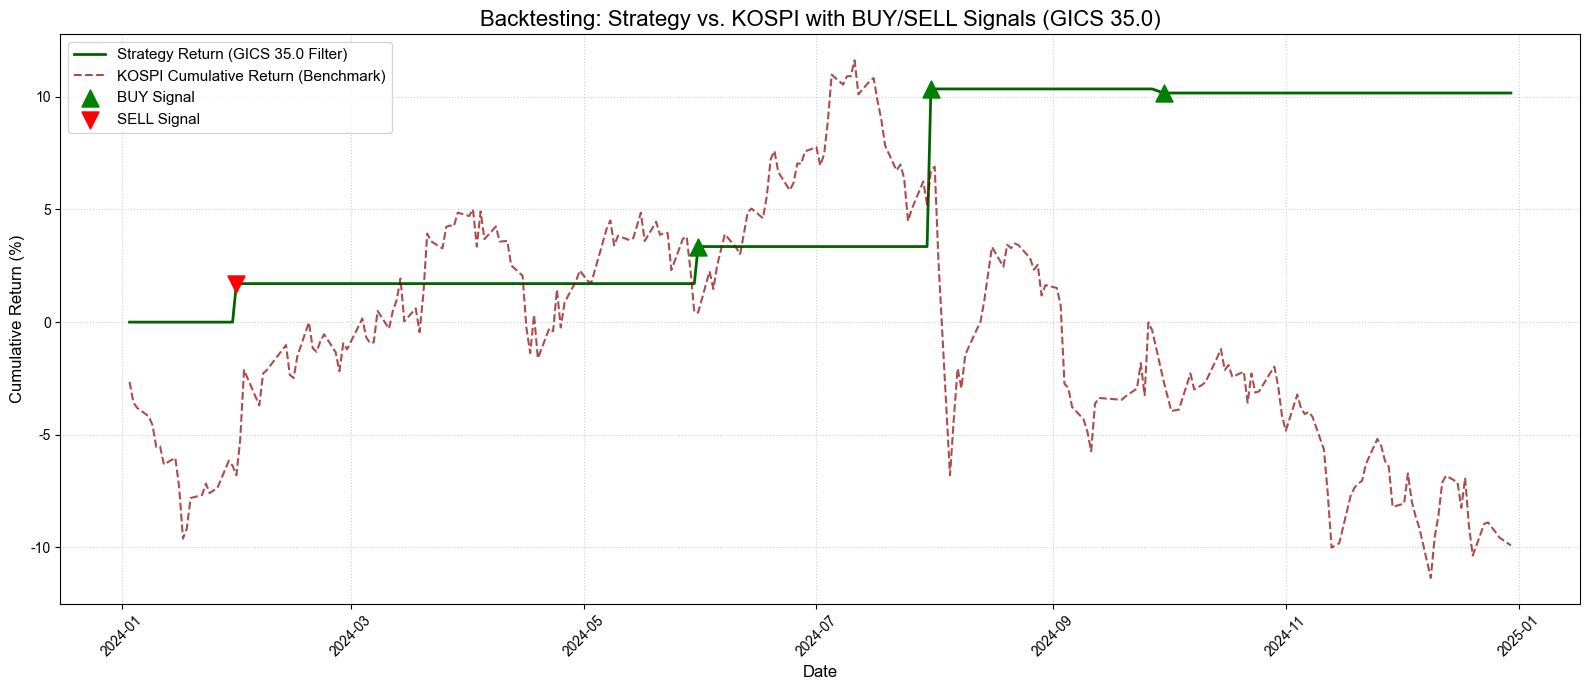


✅ Visualization Complete: ../output/problem4_backtest/final_backtest_corrected_returns.png


In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import platform
from matplotlib import rc
from matplotlib import font_manager # For font configuration

# --- 1. 설정 및 최적 규칙 정의 ---
VENDOR_ANALYSIS_PATH = "../output/problem2_vendor/problem2_vendor_analysis_base.csv"
KOSPI_PATH = "../data/kospi.csv" 
GICS_PATH = "../output/gics_clean.csv"
OUT_DIR = "../output/problem4_backtest" 
os.makedirs(OUT_DIR, exist_ok=True)

# 확정된 최적 규칙 (이전 단계 결과 사용)
TARGET_SECTOR = 35.0 
Z_SCORE_THRESHOLD = 2.0 
VALIDATION_START_DATE = pd.to_datetime('2024-01-01')

# Matplotlib 폰트 설정 (한글 관련 설정 모두 제거)
# 영문 폰트를 사용하도록 설정
rc('font', family='Arial') 
plt.rcParams['axes.unicode_minus'] = False 


# --- 2. 데이터 로드 및 규칙 적용 ---
print("-> 1. Data Loading and Rule Application...")

try:
    # A. Price Data Load (for Strategy Return Calculation)
    df_full = pd.read_csv(
        VENDOR_ANALYSIS_PATH, 
        usecols=['symbol', 'date', 'surprise_z', 'return_post_1d'],
        dtype={'surprise_z': np.float32, 'return_post_1d': np.float64}
    ).dropna(subset=['surprise_z', 'return_post_1d'])
    df_full['date'] = pd.to_datetime(df_full['date'])
    df_validation = df_full[df_full['date'] >= VALIDATION_START_DATE].copy()

    # B. KOSPI Index Load
    df_kospi = pd.read_csv(KOSPI_PATH)
    df_kospi = df_kospi.rename(columns={df_kospi.columns[0]: 'date', df_kospi.columns[1]: 'kospi_index'})
    df_kospi['date'] = pd.to_datetime(df_kospi['date'], format='%Y%m%d')
    df_kospi = df_kospi[df_kospi['date'] >= VALIDATION_START_DATE].copy()

    # C. GICS Sector Load
    df_gics = pd.read_csv(GICS_PATH, usecols=['symbol', 'sector'])
    df_gics['sector'] = df_gics['sector'].astype(np.float64) 
    
    # D. Training Set Stats (Z-Score boundary)
    df_train = df_full[df_full['date'] < VALIDATION_START_DATE]
    TRAIN_MEAN_Z = df_train['surprise_z'].mean()
    TRAIN_STD_Z = df_train['surprise_z'].std()
    
    # E. GICS 병합 및 최종 규칙 적용
    df_validation = pd.merge(df_validation, df_gics, on='symbol', how='left')
    df_validation = df_validation.dropna(subset=['sector', 'return_post_1d'])

    def apply_final_rule(row):
        if row['sector'] != TARGET_SECTOR:
            return 'HOLD'
        
        is_buy = row['surprise_z'] > TRAIN_MEAN_Z + Z_SCORE_THRESHOLD * TRAIN_STD_Z
        is_sell = row['surprise_z'] < TRAIN_MEAN_Z - Z_SCORE_THRESHOLD * TRAIN_STD_Z
        
        if is_buy:
            return 'BUY'
        elif is_sell:
            return 'SELL'
        else:
            return 'HOLD'

    df_validation['decision'] = df_validation.apply(apply_final_rule, axis=1)

except FileNotFoundError as e:
    print(f"❌ Error: Required file not found. Please check paths: {e}")
    exit()
except Exception as e:
    print(f"❌ Error: Unexpected error during data processing: {e}")
    exit()


# --- 3. 전략 및 벤치마크 일별 수익률 Stream 생성 (SELL 수익 반영 수정) ---

# A. KOSPI 일별 수익률 계산 (벤치마크)
df_kospi['kospi_return'] = df_kospi['kospi_index'].pct_change()
df_daily_returns = df_kospi.set_index('date').dropna(subset=['kospi_return'])
df_daily_returns['strategy_return'] = 0.0

# B. 전략 일별 실제 수익률 계산 (BUY는 그대로, SELL은 반전)
# df_validation에 새로운 컬럼 'strategy_trade_return' 생성 (숏 수익 반영)
df_validation['strategy_trade_return'] = np.where(
    df_validation['decision'] == 'SELL', 
    # SELL: return_post_1d가 -1.7%이면, 수익은 +1.7%이므로 부호를 반전
    -df_validation['return_post_1d'], 
    # BUY: return_post_1d가 +1.9%이면, 수익은 +1.9%로 그대로 사용
    df_validation['return_post_1d']
)

# C. 시그널 발생일의 평균 전략 수익률 (Average Strategy Return per Day)
# 시그널이 발생한 날짜에 전략 수익률을 반영합니다.
df_signals_daily_mean = df_validation[df_validation['decision'].isin(['BUY', 'SELL'])] \
                           .groupby('date')['strategy_trade_return'].mean()

for date, avg_return in df_signals_daily_mean.items():
    if date in df_daily_returns.index:
        df_daily_returns.loc[date, 'strategy_return'] = avg_return

# D. 누적 수익률 계산
df_daily_returns['kospi_cumulative'] = (1 + df_daily_returns['kospi_return']).cumprod() - 1
df_daily_returns['strategy_cumulative'] = (1 + df_daily_returns['strategy_return']).cumprod() - 1

# E. 시그널 발생 날짜/타입 추출 (마커용)
df_markers = df_validation[df_validation['decision'].isin(['BUY', 'SELL'])].drop_duplicates(subset=['date', 'decision']).copy()
df_markers = pd.merge(df_markers, df_daily_returns[['strategy_cumulative']], left_on='date', right_index=True, how='inner')


# --- 4. 시각화 (백테스팅 + 시그널 마커) ---
print("\n➡️ 4. Generating Backtest Visualization with Corrected Returns...")

plt.figure(figsize=(16, 7))

# 1. Strategy Cumulative Return (Green Line)
plt.plot(df_daily_returns.index, df_daily_returns['strategy_cumulative'] * 100, 
         label=f"Strategy Return (GICS {TARGET_SECTOR:.1f} Filter)", color='darkgreen', linewidth=2)

# 2. KOSPI Cumulative Return (Red Dashed Line)
plt.plot(df_daily_returns.index, df_daily_returns['kospi_cumulative'] * 100, 
         label='KOSPI Cumulative Return (Benchmark)', color='darkred', linestyle='--', alpha=0.7)

# 3. BUY/SELL Signal Markers 
buy_signals = df_markers[df_markers['decision'] == 'BUY']
sell_signals = df_markers[df_markers['decision'] == 'SELL']

# BUY markers (Green Up Triangle)
plt.scatter(
    buy_signals['date'], 
    buy_signals['strategy_cumulative'] * 100, 
    color='green', 
    marker='^', 
    s=150, 
    label='BUY Signal', 
    zorder=5
)

# SELL markers (Red Down Triangle)
plt.scatter(
    sell_signals['date'], 
    sell_signals['strategy_cumulative'] * 100, 
    color='red', 
    marker='v', 
    s=150, 
    label='SELL Signal', 
    zorder=5
)


# Chart Styling (English only)
plt.title(f"Backtesting: Strategy vs. KOSPI with BUY/SELL Signals (GICS {TARGET_SECTOR:.1f})", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return (%)", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plot_path = os.path.join(OUT_DIR, "final_backtest_corrected_returns.png")
plt.savefig(plot_path)
plt.show()

print(f"\n✅ Visualization Complete: {plot_path}")